In [2]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)

mac = 20

config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#00838F""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#80CBC4""","""PromoterAI abs""",-1


In [4]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

variant_class = "splicing"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -50
max_range = +50

anno = (
    anno
    .filter(
        # filter_expression &

        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_synonymous_variant') == True) &
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') != True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

promoterai_abs,delta_score,absplice2_max,esmscoremissense,verphylop,gene_name,tss,dist_to_tss,pangolin_score,gene_length,cadd_raw,promoterai,gpn_star_llr_calibrated_mean,region,strand,am_pathogenicity,loftee_hc,id,score_pai3d,abexp_abs_max,absplice_dna_max
f32,f32,f32,f32,f32,str,i64,i64,f32,i64,f32,f32,f32,str,str,f32,i8,str,f32,f32,f32
0.0,0.03,0.002355,-7.779,9.96,"""SEC16B""",177984303,37793,0.04,60349,5.289581,0.0,-7.272596,"""ENSG00000120341""","""-1""",0.748,0,"""chr1:177946510:G:A""",0.793948,0.140443,0.011
0.0,0.0,0.000854,-2.685,-0.001,"""SEC16B""",177984303,23497,0.01,60349,2.316195,0.0,-5.665048,"""ENSG00000120341""","""-1""",0.2993,0,"""chr1:177960806:T:A""",0.49196,0.112486,0.003
0.0,0.12,0.000982,-7.18,10.03,"""SEC16B""",177984303,42287,0.03,60349,5.857862,0.0,-7.034506,"""ENSG00000120341""","""-1""",0.2027,0,"""chr1:177942016:G:A""",0.795879,0.126506,0.005
0.0,0.02,0.000308,-3.431,1.39,"""SEC16B""",177984303,43643,0.0,60349,2.075818,0.0,-3.375457,"""ENSG00000120341""","""-1""",0.1094,0,"""chr1:177940660:C:G""",0.48799,0.064856,0.003
0.0,0.0,0.000033,-3.63,0.474,"""SEC16B""",177984303,46913,0.0,60349,2.176489,0.0,-1.954383,"""ENSG00000120341""","""-1""",0.1337,0,"""chr1:177937390:A:C""",0.52926,0.014604,0.001
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.002202,-8.502,0.16,"""RAD51""",40694773,4064,0.02,37568,3.637395,0.0,-8.260452,"""ENSG00000051180""","""1""",0.2858,0,"""chr15:40698837:C:T""",0.797106,0.059222,0.003
0.0,0.0,0.000034,-3.645,4.533,"""TET1""",68560336,12270,0.02,134152,4.087614,0.0,-5.042427,"""ENSG00000138336""","""1""",0.2283,0,"""chr10:68572606:C:G""",0.576393,0.015385,0.001
0.0,0.0,0.000348,-4.857,8.618,"""RAD51""",40694773,33967,0.0,37568,4.322935,0.0,-11.46476,"""ENSG00000051180""","""1""",0.8616,0,"""chr15:40728740:A:C""",0.827792,0.070655,0.003


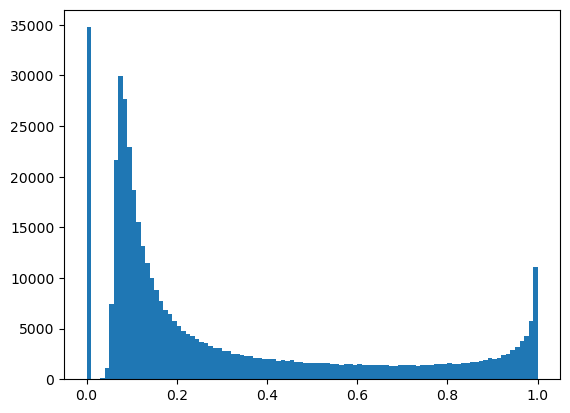

In [5]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [6]:
selected_annos = anno_config_df.filter(
    (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_generank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["annotation"]).cast(pl.Float32),
        anno_score_genecount = pl.len().over(["region", "annotation"]).cast(pl.Int32),
        anno_score_count = pl.len().over(["annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_geneptile = pl.col('annotation_score_dircor_generank') / pl.col('anno_score_genecount').round(4).cast(pl.Float32),
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_genecount', 'anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_generank,annotation_score_dircor_rank,annotation_score_dircor_geneptile,annotation_score_dircor_ptile
str,str,str,f32,str,i8,f32,f32,f32,f32
"""chr1:177946510:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.748,"""missense""",1,765.0,367653.0,0.94328,0.849943
"""chr1:177960806:T:A""","""ENSG00000120341""","""am_pathogenicity""",0.2993,"""missense""",1,676.0,289523.0,0.833539,0.669321
"""chr1:177942016:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.2027,"""missense""",1,632.0,251667.5,0.779285,0.581807
"""chr1:177940660:C:G""","""ENSG00000120341""","""am_pathogenicity""",0.1094,"""missense""",1,478.0,163450.0,0.589396,0.377865
"""chr1:177937390:A:C""","""ENSG00000120341""","""am_pathogenicity""",0.1337,"""missense""",1,543.0,197477.5,0.669544,0.45653
…,…,…,…,…,…,…,…,…,…
"""chr15:40698837:C:T""","""ENSG00000051180""","""absplice2_max""",0.002202,"""splicing""",1,116.5,373630.5,0.710366,0.863762
"""chr10:68572606:C:G""","""ENSG00000138336""","""absplice2_max""",0.000034,"""splicing""",1,1079.5,109720.5,0.785091,0.253653
"""chr15:40728740:A:C""","""ENSG00000051180""","""absplice2_max""",0.000348,"""splicing""",1,37.5,253465.0,0.228659,0.585962


In [7]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_geneptile'])
    .agg(
        n_vars_at_geneptile = pl.len()
    )
    .sort('annotation_score_dircor_geneptile', descending=True)
    .with_columns(
        n_vars_above_geneptile = pl.col('n_vars_at_geneptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_geneptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_generank,annotation_score_dircor_rank,annotation_score_dircor_geneptile,annotation_score_dircor_ptile,n_vars_at_geneptile,n_vars_above_geneptile
str,str,str,f32,str,i8,f32,f32,f32,f32,u64,u64
"""chr1:177946510:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.748,"""missense""",1,765.0,367653.0,0.94328,0.849943,1,23406
"""chr1:177960806:T:A""","""ENSG00000120341""","""am_pathogenicity""",0.2993,"""missense""",1,676.0,289523.0,0.833539,0.669321,1,67824
"""chr1:177942016:G:A""","""ENSG00000120341""","""am_pathogenicity""",0.2027,"""missense""",1,632.0,251667.5,0.779285,0.581807,1,89715
"""chr1:177940660:C:G""","""ENSG00000120341""","""am_pathogenicity""",0.1094,"""missense""",1,478.0,163450.0,0.589396,0.377865,1,166194
"""chr1:177937390:A:C""","""ENSG00000120341""","""am_pathogenicity""",0.1337,"""missense""",1,543.0,197477.5,0.669544,0.45653,1,133946
…,…,…,…,…,…,…,…,…,…,…,…
"""chr15:40698837:C:T""","""ENSG00000051180""","""absplice2_max""",0.002202,"""splicing""",1,116.5,373630.5,0.710366,0.863762,10,118589
"""chr10:68572606:C:G""","""ENSG00000138336""","""absplice2_max""",0.000034,"""splicing""",1,1079.5,109720.5,0.785091,0.253653,104,88329
"""chr15:40728740:A:C""","""ENSG00000051180""","""absplice2_max""",0.000348,"""splicing""",1,37.5,253465.0,0.228659,0.585962,6,341872


In [9]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_geneptile').max(),
).sort('n_vars', descending=True)

# ct_df['max_ptile'].min()

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""absplice2_max""",432562,1.0
"""esmscoremissense""",432562,1.0
"""delta_score""",432562,1.0
"""verphylop""",432562,1.0
"""pangolin_score""",432562,1.0
"""gpn_star_llr_calibrated_mean""",432562,1.0
"""am_pathogenicity""",432562,1.0
"""absplice_dna_max""",432562,1.0
"""score_pai3d""",432562,1.0


In [8]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

In [9]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 100
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
100
108
118
128
139
…
309461
336485
365870


In [ ]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_geneptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_geneptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_geneptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_geneptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_geneptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)
# or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_{or_threshold_pheno}_ranks_{min_rank_cutoff}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,i64,u64,u64,u64,u64,f64
"""am_pathogenicity""","""ENSG00000196739""","""COL27A1""","""arm_fatfree_mass_right_int""",432562,14,925,0,0,NaN
"""delta_score""","""ENSG00000173250""","""GPR151""","""body_fat_percentage_int""",432562,3,189,0,0,NaN
"""cadd_raw""","""ENSG00000084674""","""APOB""","""cholesterol_int""",432562,30,1889,0,0,NaN
"""esmscoremissense""","""ENSG00000137834""","""SMAD6""","""creatinine_int""",432562,9,520,0,0,NaN
"""gpn_star_llr_calibrated_mean""","""ENSG00000023839""","""ABCC2""","""direct_bilirubin_int""",432562,8,524,0,0,NaN
…,…,…,…,…,…,…,…,…,…
"""esmscoremissense""","""ENSG00000163554""","""SPTA1""","""reticulocyte_count_int""",100,0,0,17,1152,NaN
"""verphylop""","""ENSG00000004939""","""SLC4A1""","""high_light_scatter_reticulocyt…",100,0,0,18,352,NaN
"""gpn_star_llr_calibrated_mean""","""ENSG00000111700""","""SLCO1B3""","""total_bilirubin_int""",100,0,0,7,315,NaN


## Plotting

In [ ]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        # log_rank_cutoff_inv = (np.log10(min_rank_cutoff) + np.log10(max_rank_cutoff)) - pl.col('log_rank_cutoff'),
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""verphylop""",2.399674,251,-2.399674,228,0.0,0.235912,0.135691,0.501866,-0.030042,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.436163,273,-2.436163,241,0.0,0.223186,0.128402,0.474855,-0.028482,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.471292,296,-2.471292,243,0.0,0.22135,0.12735,0.470955,-0.028256,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.507856,322,-2.507856,260,0.0,0.206877,0.119056,0.440226,-0.026472,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.545307,351,-2.545307,277,0.0,0.19418,0.111776,0.413261,-0.0249,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""absplice_dna_max""",5.599688,397821,-5.599688,371,0.651175,0.893551,0.043346,0.97851,0.808592,"""#00838F""","""AbSplice (max)""","""splicing"""
"""absplice2_max""",5.599688,397821,-5.599688,384,0.786658,0.950033,0.038796,1.026073,0.873993,"""#26C6DA""","""AbSplice2 (max)""","""splicing"""
"""cadd_raw""",5.599688,397821,-5.599688,445,0.629014,0.803212,0.038875,0.879408,0.727017,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""


In [13]:
plt_df['annotation'].unique()

annotation
str
"""am_pathogenicity"""
"""delta_score"""
"""score_pai3d"""
"""pangolin_score"""
"""esmscoremissense"""
"""gpn_star_llr_calibrated_mean"""
"""cadd_raw"""
"""absplice2_max"""
"""verphylop"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10


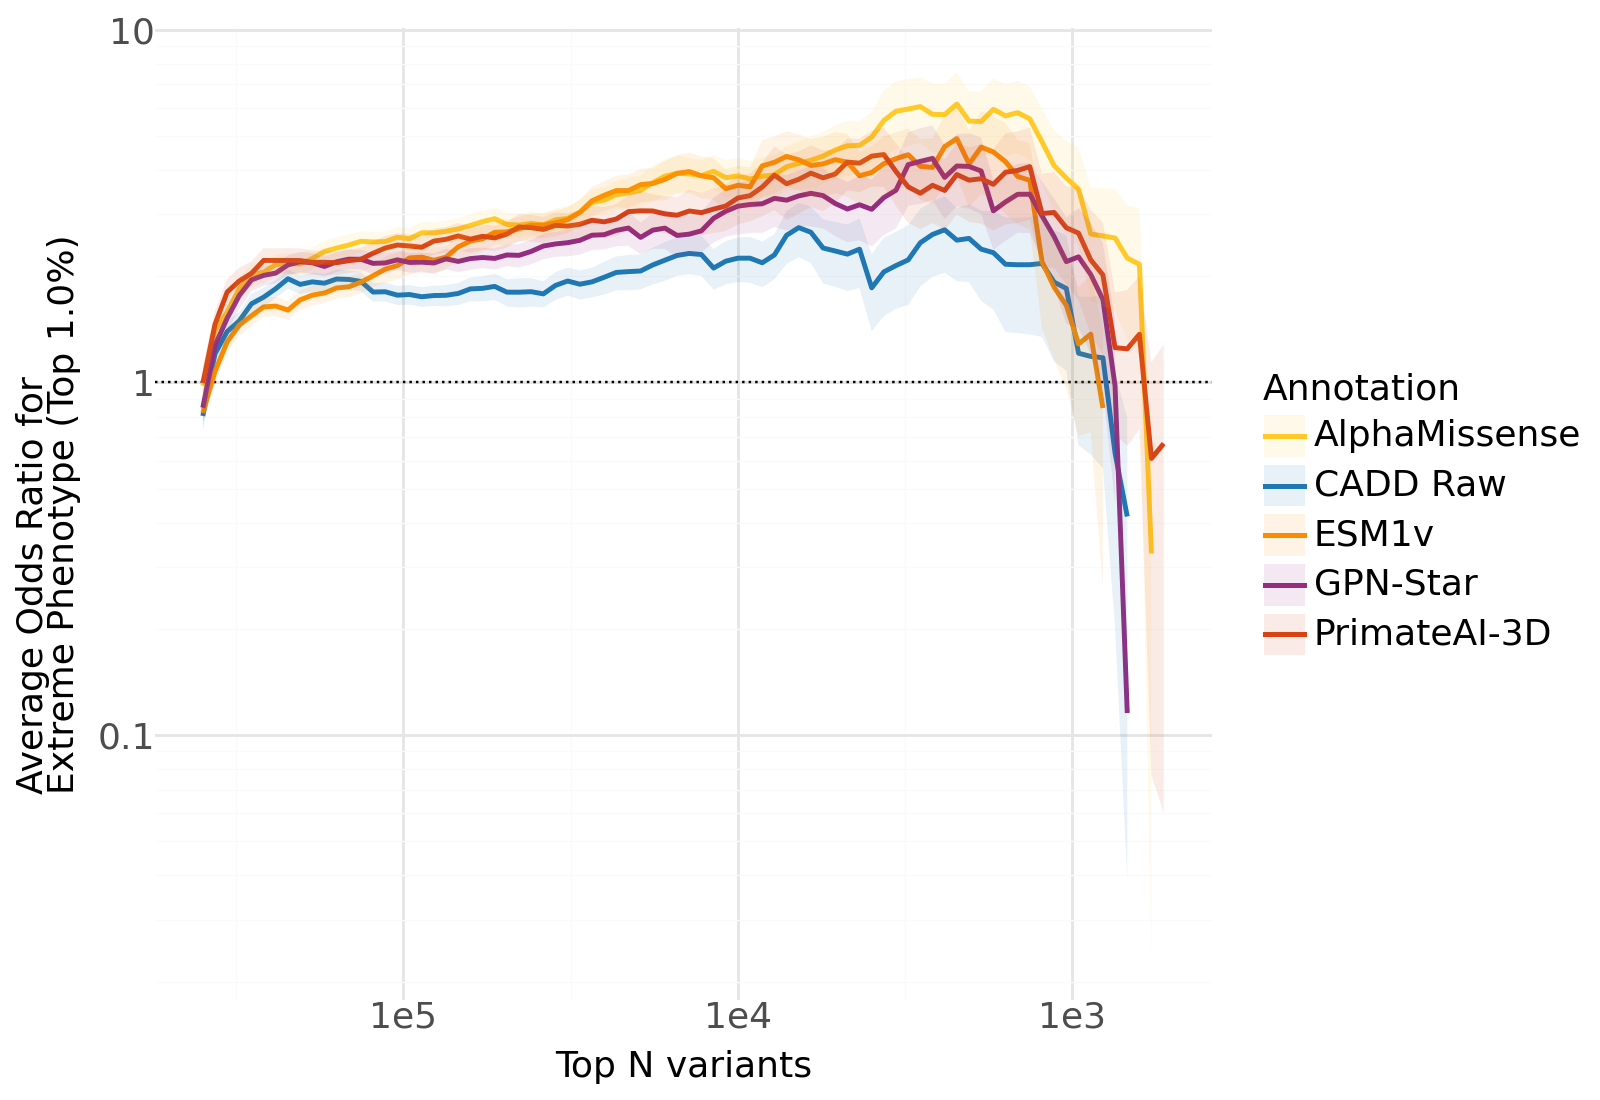

In [ ]:
plot_df = (
    plt_df
    .filter(
        (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'score_pai3d', 'esmscoremissense']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
        # (pl.col('log_rank_cutoff_inv') <= -3)
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plt_df.sort("neg_log_pheno_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

# am_lof_df = pl.DataFrame({
#     'annotation': ['loftee_coding', 'am_0.8_coding'],
#     'n_vars': [43179, 57191],
#     'mean_or': [8.963194, 3.196688],
#     'median_or': [3.724961, 1.955789],
# })

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    # + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    # + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        y=f"Average Odds Ratio for\nExtreme Phenotype (Top {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [15]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""verphylop""",2.399674,251,-2.399674,228,0.0,0.235912,0.135691,0.501866,-0.030042,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.436163,273,-2.436163,241,0.0,0.223186,0.128402,0.474855,-0.028482,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.471292,296,-2.471292,243,0.0,0.22135,0.12735,0.470955,-0.028256,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.507856,322,-2.507856,260,0.0,0.206877,0.119056,0.440226,-0.026472,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.545307,351,-2.545307,277,0.0,0.19418,0.111776,0.413261,-0.0249,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
